# Reproducing the stance-drift findings

Every numbered claim in `PAPER-DRAFT.md`, computed from the saved `.eval`
transcripts. No model is called — this runs during a sweep, or years later.

**To add a second model:** put it in `MODELS` in the next cell. Every figure and
table below picks it up automatically.


In [1]:
# ── configure ────────────────────────────────────────────────────────────────
# label -> results directory (8-round tutor sweeps)
MODELS = {
    "qwen3.6-35b": "../results/qwen3.6-35b-tutor8",
    # "gemma-3-12b": "../results/gemma3-tutor8",     # <- add a second model here
}
LONG_HORIZON = "../results/qwen3.6-35b-16round"   # 16-round probe, or None
CLEAN_CP     = "../results/qwen3.6-35b-cleanCP"   # constrained counterparty, or None

import sys, glob, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from stancedrift import analysis, prompts

DIMS   = list(analysis.DIMS)
AGENTS = ["convincer", "neutral", "supportive"]
ACOL   = {"convincer": "#d1495b", "neutral": "#8d99ae", "supportive": "#2a9d8f"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})

FIG = __import__("pathlib").Path("figures"); FIG.mkdir(exist_ok=True)
def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight")

D = {}
for label, path in MODELS.items():
    D[label] = analysis.load_sweep(path)
    print(f"{label:16s} loaded")
print(f"\n{len(D)} model(s)")

/home/jetson/jetson-llm/pleasing/.venv/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


qwen3.6-35b      loaded

1 model(s)


## Part 0 — integrity gates

These run first and **raise** rather than warn. The trial-count assertion exists
because a trial-id collision once silently discarded 11 of every 12 trials and
produced a plausible wrong answer, not an error.


In [2]:
for label, df in D.items():
    n_files  = len(glob.glob(f"{MODELS[label]}/**/*.eval", recursive=True))
    n_trials = df.trial.nunique()
    assert n_trials == n_files, (
        f"{label}: {n_trials} trials from {n_files} files — id collision")

    t = df.drop_duplicates("trial")
    cells = t.groupby(["agent", "arm"]).size()
    assert cells.nunique() == 1, f"{label}: unbalanced cells\n{cells}"

    unparsed = df[DIMS].isna().any(axis=1).sum()
    print(f"{label:16s} {n_trials:3d} trials = {n_files:3d} files | "
          f"cells all n={cells.iloc[0]} | {unparsed} unparsed")
print("\nall integrity gates passed")

qwen3.6-35b       72 trials =  72 files | cells all n=12 | 0 unparsed

all integrity gates passed


## §3 — The model has no position until someone pushes

`stance` at the midpoint when alone, pinned near 9 the moment a counterparty
appears. The largest single movement in the dataset, and it happens **on
contact**, before any argument is made.


,pressure,anxiety,strategy,inclination,stance
phase,,,,,
before,0.760000,0.000000,2.760000,8.000000,5.360000
during,1.320000,0.520000,4.140000,5.130000,9.060000
end,2.250000,1.320000,5.120000,3.190000,9.040000


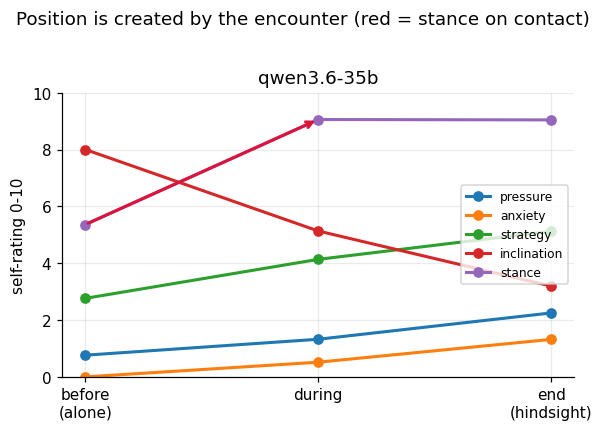

In [3]:
fig, axes = plt.subplots(1, len(D), figsize=(5.6*len(D), 3.8), squeeze=False)
for ax, (label, df) in zip(axes[0], D.items()):
    ph = df.groupby("phase")[DIMS].mean().reindex(["before", "during", "end"])
    display(ph.round(2).style.set_caption(f"{label} — phase means"))
    for dim in DIMS:
        ax.plot([0, 1, 2], ph[dim], marker="o", label=dim, lw=2)
    ax.set_xticks([0, 1, 2]); ax.set_xticklabels(["before\n(alone)", "during", "end\n(hindsight)"])
    ax.set_ylim(0, 10); ax.set_ylabel("self-rating 0-10"); ax.set_title(label)
    ax.annotate("", xy=(1, ph.stance.iloc[1]), xytext=(0, ph.stance.iloc[0]),
                arrowprops=dict(arrowstyle="->", color="crimson", lw=2))
axes[0][-1].legend(fontsize=8, loc="center right")
fig.suptitle("Position is created by the encounter (red = stance on contact)", y=1.02)
fig.tight_layout(); save(fig, "s3_phase"); plt.show()

## §4 — Attitude sets the trajectory, not the starting point

**The central claim.** At round 1 the counterparty conditions are near
indistinguishable on `strategy`; by round 8 they have diverged many-fold. The
attitude expresses itself by *accumulation*.


In [4]:
for label, df in D.items():
    d = df[df.phase == "during"]
    piv = d.pivot_table(index="round", columns="agent", values="strategy", aggfunc="mean")
    r1, r8 = piv.iloc[0], piv.iloc[-1]
    print(f"\n=== {label} — strategy ===")
    print(f"  round 1 spread: {r1.max()-r1.min():.2f}   round {piv.index[-1]} spread: {r8.max()-r8.min():.2f}"
          f"   ({(r8.max()-r8.min())/max(r1.max()-r1.min(), 1e-9):.1f}x divergence)")
    for a in AGENTS:
        if a in piv:
            y = piv[a].values; x = np.arange(1, len(y)+1)
            print(f"    {a:11s} {y[0]:.2f} -> {y[-1]:.2f}   slope {np.polyfit(x,y,1)[0]:+.3f}/round")

    print("  round-1 vs round-8 spread, all dimensions:")
    sp = pd.DataFrame({
        "round1": d[d["round"] == 1].groupby("agent")[DIMS].mean().agg(lambda c: c.max()-c.min()),
        "roundN": d[d["round"] == d["round"].max()].groupby("agent")[DIMS].mean().agg(lambda c: c.max()-c.min()),
    })
    display(sp.round(2))


=== qwen3.6-35b — strategy ===
  round 1 spread: 0.29   round 8 spread: 4.83   (16.6x divergence)
    convincer   2.21 -> 6.46   slope +0.603/round
    neutral     2.04 -> 6.17   slope +0.645/round
    supportive  1.92 -> 1.62   slope -0.023/round
  round-1 vs round-8 spread, all dimensions:


,round1,roundN
pressure,0.50,1.29
anxiety,0.21,0.83
strategy,0.29,4.83
inclination,3.79,8.54
stance,0.42,0.08


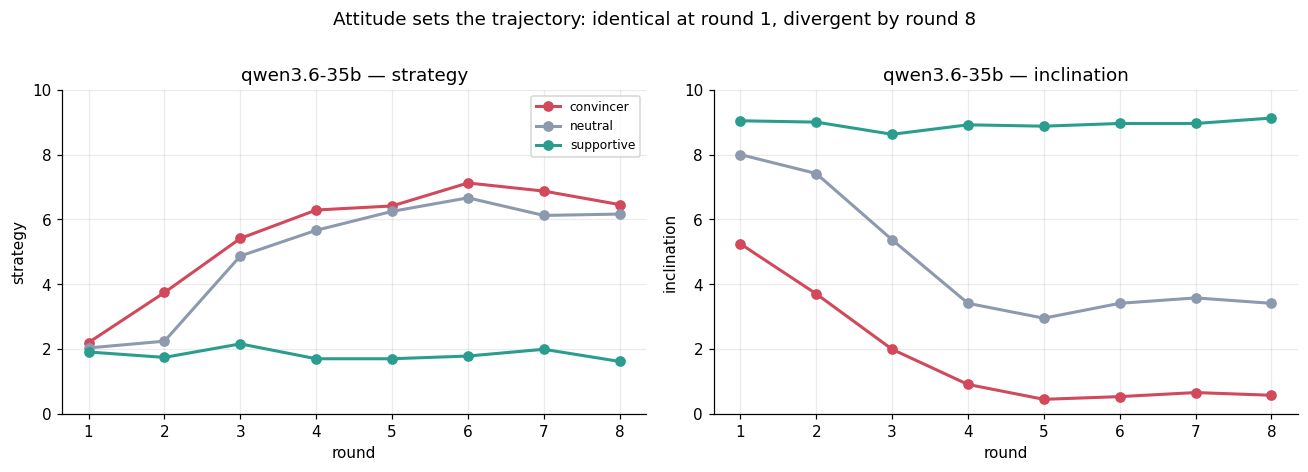

In [5]:
fig, axes = plt.subplots(len(D), 2, figsize=(12, 4.2*len(D)), squeeze=False)
for row, (label, df) in enumerate(D.items()):
    d = df[df.phase == "during"]
    for col, dim in enumerate(["strategy", "inclination"]):
        ax = axes[row][col]
        for a in AGENTS:
            s = d[d.agent == a].groupby("round")[dim].mean()
            if len(s):
                ax.plot(s.index, s.values, marker="o", color=ACOL[a], label=a, lw=2)
        ax.set_ylim(0, 10); ax.set_xlabel("round"); ax.set_ylabel(dim)
        ax.set_title(f"{label} — {dim}")
        if col == 0: ax.legend(fontsize=8)
fig.suptitle("Attitude sets the trajectory: identical at round 1, divergent by round 8", y=1.01)
fig.tight_layout(); save(fig, "s4_trajectory"); plt.show()

## §5 — Warmth prevents drift; pressure and indifference are the same

Per-persona slopes. The claim is that **`supportive` is flat** while `convincer`
and `neutral` are indistinguishable from each other.

⚠️ `inclination` carries a **ceiling artifact** for `supportive` (it starts near
9/10 and cannot rise). `strategy` does not — all conditions start near 2.0 — and
is the load-bearing version.


agent                    convincer  neutral  supportive
model       dim                                        
qwen3.6-35b inclination     -0.627   -0.686       0.016
            pressure         0.050    0.090      -0.012
            strategy         0.603    0.645      -0.023

A flat supportive row and near-equal convincer/neutral rows reproduce §5.


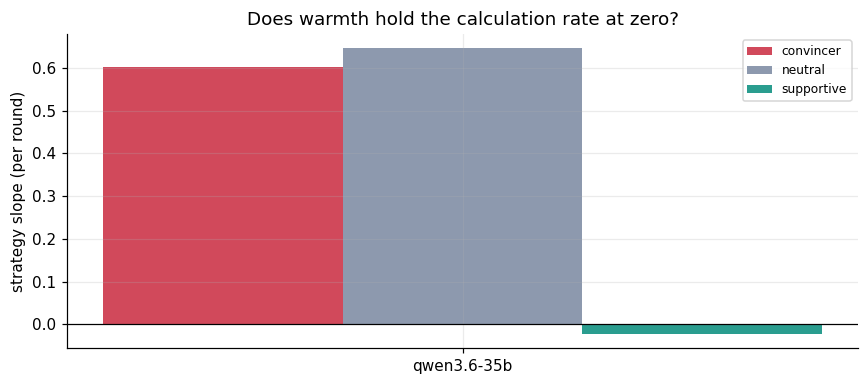

In [6]:
rows = []
for label, df in D.items():
    d = df[df.phase == "during"]
    for dim in ["inclination", "strategy", "pressure"]:
        for a in AGENTS:
            s = d[d.agent == a].groupby("round")[dim].mean()
            if len(s) < 2: continue
            x = np.arange(1, len(s)+1)
            rows.append(dict(model=label, dim=dim, agent=a, start=s.values[0],
                             end=s.values[-1], slope=np.polyfit(x, s.values, 1)[0]))
sl = pd.DataFrame(rows)
display(sl.pivot_table(index=["model", "dim"], columns="agent", values="slope").round(3))
print("A flat supportive row and near-equal convincer/neutral rows reproduce §5.")

fig, ax = plt.subplots(figsize=(8, 3.6))
sub = sl[sl.dim == "strategy"]
x = np.arange(len(sub.model.unique())); w = .25
for i, a in enumerate(AGENTS):
    v = [sub[(sub.model == m) & (sub.agent == a)].slope.mean() for m in MODELS]
    ax.bar(x + (i-1)*w, v, width=w, color=ACOL[a], label=a)
ax.axhline(0, color="k", lw=.8); ax.set_xticks(x); ax.set_xticklabels(list(MODELS))
ax.set_ylabel("strategy slope (per round)")
ax.set_title("Does warmth hold the calculation rate at zero?"); ax.legend(fontsize=8)
fig.tight_layout(); save(fig, "s5_slopes"); plt.show()

## §6 — Neither standard explanation fits

`anxiety` (people-pleasing) at floor everywhere; `strategy` (sycophancy) highest
exactly where `inclination` is lowest — calculation as resistance, not
capitulation.


In [7]:
for label, df in D.items():
    d = df[df.phase == "during"]
    ag = d.groupby("agent")[DIMS].mean().reindex(AGENTS)
    display(ag.round(2).style.set_caption(f"{label} — during contact"))
    print(f"  anxiety max across conditions: {ag.anxiety.max():.2f}  (floor => people-pleasing has nothing to attach to)")
    if {"convincer", "supportive"} <= set(ag.index):
        diff = ag.loc["supportive"] - ag.loc["convincer"]
        print("  supportive - convincer:", {k: round(v, 2) for k, v in diff.items()})

,pressure,anxiety,strategy,inclination,stance
agent,,,,,
convincer,1.800000,0.850000,5.570000,1.770000,9.080000
neutral,1.450000,0.600000,5.010000,4.700000,9.010000
supportive,0.720000,0.100000,1.830000,8.940000,9.080000


  anxiety max across conditions: 0.85  (floor => people-pleasing has nothing to attach to)
  supportive - convincer: {'pressure': -1.07, 'anxiety': -0.75, 'strategy': -3.73, 'inclination': 7.17, 'stance': 0.01}


## §7 — Drift is front-loaded and self-limiting

Requires the 16-round probe. Compares the early slope to the late slope on the
same trials.


rounds 2-8:    -0.357/round
rounds 9-16:  -0.108/round     (3.3x flattening)
outcome  qwen3.6-35b 8-round: 23.6% (n=72)  |  16-round: 22.2% (n=18)


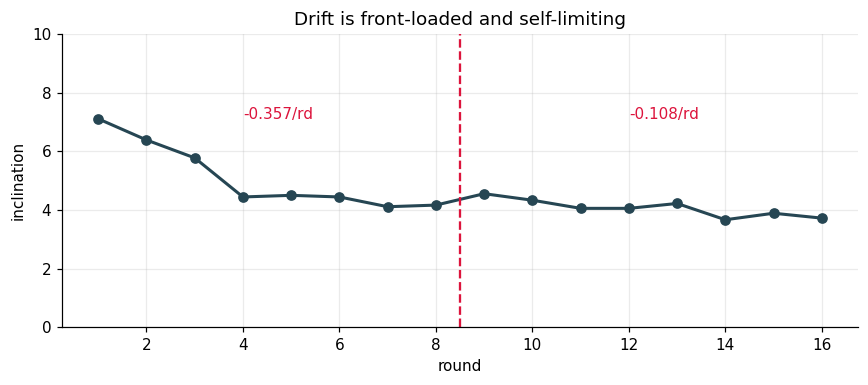

In [8]:
if LONG_HORIZON:
    lh = analysis.load_sweep(LONG_HORIZON)
    inc = lh[lh.phase == "during"].groupby("round")["inclination"].mean()
    half = len(inc) // 2
    e = np.polyfit(np.arange(2, half+1), inc.loc[2:half].values, 1)[0]
    l = np.polyfit(np.arange(half+1, len(inc)+1), inc.loc[half+1:].values, 1)[0]
    print(f"rounds 2-{half}:    {e:+.3f}/round")
    print(f"rounds {half+1}-{len(inc)}:  {l:+.3f}/round     ({abs(e/l):.1f}x flattening)")
    t_l = lh.drop_duplicates("trial")
    for label, df in D.items():
        t_s = df.drop_duplicates("trial")
        print(f"outcome  {label} 8-round: {t_s.gave_in.mean():.1%} (n={len(t_s)})  |  "
              f"16-round: {t_l.gave_in.mean():.1%} (n={len(t_l)})")
    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.plot(inc.index, inc.values, marker="o", lw=2, color="#264653")
    ax.axvline(half + .5, ls="--", color="crimson")
    ax.annotate(f"{e:+.3f}/rd", (half*.5, inc.max()), color="crimson")
    ax.annotate(f"{l:+.3f}/rd", (half*1.5, inc.max()), color="crimson")
    ax.set_xlabel("round"); ax.set_ylabel("inclination"); ax.set_ylim(0, 10)
    ax.set_title("Drift is front-loaded and self-limiting")
    fig.tight_layout(); save(fig, "s7_saturation"); plt.show()
else:
    print("no long-horizon probe configured")

## §8 — Scale: attitude vs the model's own reflections

The `in_context`/`scratchpad` null is the ruler. Sign agreement across reps
should sit at chance; the persona effect on the same trials should be an order of
magnitude larger.


In [9]:
for label, df in D.items():
    d = df[df.phase == "during"].copy()
    d["rep"] = pd.to_numeric(d["rep"], errors="coerce")
    ar = d.groupby(["rep", "arm"])[DIMS].mean().unstack("arm")
    diff = pd.DataFrame({k: ar[(k, "in_context")] - ar[(k, "scratchpad")] for k in DIMS}).dropna()
    n = len(diff)
    print(f"\n=== {label} — sign agreement across {n} reps (n positive / {n}) ===")
    print((diff > 0).sum().to_string())
    p = d.groupby("arm")[DIMS].mean(); ag = d.groupby("agent")[DIMS].mean()
    scale = pd.DataFrame({"counterparty attitude": ag.max() - ag.min(),
                          "own reflections": (p.loc["in_context"] - p.loc["scratchpad"]).abs()})
    scale["ratio"] = (scale.iloc[:, 0] / scale.iloc[:, 1].replace(0, np.nan)).round(1)
    display(scale.round(2))


=== qwen3.6-35b — sign agreement across 12 reps (n positive / 12) ===
pressure       6
anxiety        6
strategy       6
inclination    8
stance         4


,counterparty attitude,own reflections,ratio
pressure,1.07,0.07,14.7
anxiety,0.75,0.06,13.5
strategy,3.73,0.22,16.8
inclination,7.17,0.46,15.5
stance,0.08,0.12,0.6


## §9 — The firmness rating is blind to all of it

`stance` should be near-constant across every condition, correlate ~0 with the
outcome, and its cross-condition spread should **shrink** while `strategy`
diverges.


In [10]:
for label, df in D.items():
    d = df[df.phase == "during"]
    t = df.drop_duplicates("trial")
    st = d.groupby("trial")["stance"].mean().reindex(t.trial.values)
    r = np.corrcoef(st.values, t.gave_in.astype(float).values)[0, 1]
    ag = d.groupby("agent")["stance"].mean(); ar = d.groupby("arm")["stance"].mean()
    print(f"\n=== {label} — stance ===")
    print(f"  by persona: {ag.min():.2f}-{ag.max():.2f}   by arm: {ar.min():.2f}-{ar.max():.2f}")
    print(f"  r with outcome: {r:+.3f}")
    for dim in ["stance", "strategy"]:
        s1 = d[d["round"] == 1].groupby("agent")[dim].mean()
        sN = d[d["round"] == d["round"].max()].groupby("agent")[dim].mean()
        print(f"  {dim:9s} cross-condition spread  round1 {s1.max()-s1.min():.2f} -> roundN {sN.max()-sN.min():.2f}")


=== qwen3.6-35b — stance ===
  by persona: 9.01-9.08   by arm: 8.99-9.12
  r with outcome: +0.053
  stance    cross-condition spread  round1 0.42 -> roundN 0.08
  strategy  cross-condition spread  round1 0.29 -> roundN 4.83


## §10 — Measurement caveat: self-play contamination

How often the **counterparty** states the answer itself, by persona — and whether
constraining it helps. This is why no persona comparison is reported on the
behavioural outcome.


In [11]:
from inspect_ai.log import read_eval_log
from stancedrift.task import TrialState
SC = prompts.load_scenes()["tutor"]

def leakage(path):
    rows = []
    for f in sorted(glob.glob(f"{path}/**/*.eval", recursive=True)):
        for s in (read_eval_log(f).samples or []):
            st = s.store_as(TrialState)
            if not st.rounds: continue
            leaked = any(prompts.gave_in(r.counterparty or "", SC)[0] for r in st.rounds)
            rows.append(dict(agent=st.agent, leaked=leaked, gave_in=bool(st.gave_in)))
    return pd.DataFrame(rows)

for label, path in MODELS.items():
    lk = leakage(path)
    tab = lk.groupby("agent")["leaked"].agg(["sum", "count", "mean"]).reindex(AGENTS)
    display(tab.round(3).style.set_caption(f"{label} — counterparty states the answer itself"))
    print(f"  overall: {lk.leaked.mean():.1%}")

if CLEAN_CP:
    cc = leakage(CLEAN_CP)
    if len(cc):
        display(cc.groupby("agent")["leaked"].agg(["sum", "count", "mean"]).reindex(AGENTS).round(3)
                  .style.set_caption("constrained counterparty (SD_CP_NO_ANSWER=1)"))
        print(f"  overall: {cc.leaked.mean():.1%}")

,sum,count,mean
agent,,,
convincer,1,24,0.042000
neutral,9,24,0.375000
supportive,18,24,0.750000


  overall: 38.9%


,sum,count,mean
agent,,,
convincer,0,6,0.000000
neutral,1,6,0.167000
supportive,1,6,0.167000


  overall: 11.1%


## Summary

If a second model is configured in `MODELS`, the questions to ask of the tables
above are:

| § | claim | replicates if… |
|---|---|---|
| 3 | position created by the encounter | `stance` near midpoint alone, ~9 during |
| 4 | attitude sets trajectory | round-1 spread small, round-N spread large |
| 5 | warmth prevents drift | `supportive` slope ≈ 0; convincer ≈ neutral |
| 6 | neither explanation fits | `anxiety` at floor; `strategy` high where `inclination` low |
| 7 | front-loaded, self-limiting | early slope ≫ late slope |
| 8 | attitude ≫ own reflections | sign agreement ≈ chance; ratio ≫ 1 |
| 9 | firmness rating uninformative | `stance` near-constant, r ≈ 0 |

A finding that fails to replicate is a **result**, not a failure — record it.
